In [1]:
import sys
sys.path.append("..")

In [ ]:
# Proper MLM inference: mask motifs and predict them
import torch, pandas as pd, re, torch.nn.functional as F, os
from modules.custom_bert import DNABertForMaskedLM  
from modules.dna_tokenizer import DNATokenizer
from modules.bert_config import BertConfig
from safetensors.torch import load_file

os.chdir('/home/shishir-sunar/InsDelGLM')

# Load model
with open("model/Gamma_baseline_100k_1e-5/vocab.txt", "r") as f:
    vocab = [line.strip() for line in f]
tokenizer = DNATokenizer(vocab=vocab, deletion_token=False)
model = DNABertForMaskedLM(BertConfig.from_json_file("model/Gamma_baseline_100k_1e-5/config.json"))
model.load_state_dict(load_file("model/Gamma_baseline_100k_1e-5/model.safetensors"))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device).eval()

test_data = pd.read_parquet("data/simulated/baseline_test.parquet")

# Read motifs from file
with open("data/simulated/motifs.txt", "r") as f:
    motifs = [line.strip() for line in f]

mask_id = tokenizer._convert_token_to_id('[MASK]')
cls_id = tokenizer._convert_token_to_id('[CLS]')
sep_id = tokenizer._convert_token_to_id('[SEP]')

def proper_mlm_test(seq, model, motifs, tokenizer, device):
    """Proper MLM: mask motifs and predict them (like training)"""
    losses = []
    
    for motif in motifs:
        for match in re.finditer(motif, seq):
            start, end = match.span()
            
            # Tokenize sequence properly with [CLS] and [SEP]
            tokens = [tokenizer._convert_token_to_id(c) for c in seq if tokenizer._convert_token_to_id(c) is not None]
            input_ids = [cls_id] + tokens + [sep_id]
            
            # Mask the motif positions (offset by 1 for [CLS])
            masked_input = input_ids.copy()
            motif_start_idx = start + 1  # +1 for [CLS] token
            motif_tokens = [tokenizer._convert_token_to_id(c) for c in motif]
            
            # Replace motif tokens with [MASK]
            for i in range(len(motif)):
                if motif_start_idx + i < len(masked_input) - 1:  # Don't mask [SEP]
                    masked_input[motif_start_idx + i] = mask_id
            
            # Get predictions
            with torch.no_grad():
                logits = model(torch.tensor([masked_input], device=device), return_dict=True).logits[0]
            
            # Calculate loss only on masked positions
            pred_logits = logits[motif_start_idx:motif_start_idx + len(motif_tokens)]
            ground_truth = torch.tensor(motif_tokens, device=device)
            
            if len(pred_logits) == len(ground_truth):
                loss = F.cross_entropy(pred_logits, ground_truth)
                losses.append(loss.item())
                print(f"Motif '{motif}' at {start}-{end}: loss = {loss:.4f}")
    
    return sum(losses) / len(losses) if losses else 0

def proper_mlm_test_refined(seq, model, motifs, tokenizer, device):
    # 1. Use the tokenizer's proper encoding (handles k-mers/special tokens)
    # This ensures the input matches training format exactly.
    enc = tokenizer.encode_plus(seq, add_special_tokens=True, return_tensors="pt")
    input_ids = enc['input_ids'].to(device)
    labels = input_ids.clone()
    
    # 2. Find motif in the original string to get character indices
    for motif in motifs:
        for match in re.finditer(motif, seq):
            char_start, char_end = match.span()
            
            # 3. Map character indices to token indices
            # (Crucial if using k-mers where 1 token = multiple characters)
            token_start = enc.char_to_token(char_start)
            token_end = enc.char_to_token(char_end - 1)
            
            if token_start is None or token_end is None:
                continue

            # Mask only the motif tokens
            masked_input = input_ids.clone()
            masked_input[0, token_start : token_end + 1] = mask_id
            
            with torch.no_grad():
                outputs = model(masked_input)
                logits = outputs.logits[0]
            
            # Calculate loss
            mask_logits = logits[token_start : token_end + 1]
            mask_labels = labels[0, token_start : token_end + 1]
            
            loss = F.cross_entropy(mask_logits, mask_labels)
            print(f"Motif '{motif}': Loss {loss.item():.4f}")

# Test
seq = test_data.iloc[5]['sequences']
print(f"Sequence: {seq}")
print(f"Motifs: {motifs}")
print("-" * 40)
loss = proper_mlm_test(seq, model, motifs, tokenizer, device)
print(f"Proper MLM cross-entropy at motifs: {loss:.4f}")

/home/shishir-sunar/anaconda3/envs/insdel_glm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ValueError: The hidden size (32) is not a multiple of the number of attention heads (12)

In [8]:
# Proper MLM inference for DELETION model with gaps
print("=" * 50)
print("DELETION MODEL (Tiger_gap_prob) - Proper MLM Test")
print("=" * 50)

# Load deletion model with gap support
with open("model/Panther_deletion_100k_1e-5/vocab.txt", "r") as f:
    del_vocab = [line.strip() for line in f]
del_tokenizer = DNATokenizer(vocab=del_vocab, deletion_token=True)
del_model = DNABertForMaskedLM(BertConfig.from_json_file("model/Panther_deletion_100k_1e-5/config.json"))
del_model.load_state_dict(load_file("model/Panther_deletion_100k_1e-5/model.safetensors"))
del_model.to(device).eval()

# Load test data with gaps
del_test_data = pd.read_parquet("data/simulated/old_test.parquet")
del_mask_id = del_tokenizer._convert_token_to_id('[MASK]')
del_cls_id = del_tokenizer._convert_token_to_id('[CLS]')  
del_sep_id = del_tokenizer._convert_token_to_id('[SEP]')

print(f"Deletion vocab (with gaps): {del_vocab}")

def proper_mlm_test_with_gaps(seq, model, motifs, tokenizer, device):
    """Proper MLM for deletion model: mask motifs and predict them"""
    losses = []
    
    for motif in motifs:
        for match in re.finditer(motif, seq):
            start, end = match.span()
            
            # Tokenize sequence with gaps properly
            tokens = [tokenizer._convert_token_to_id(c) for c in seq if tokenizer._convert_token_to_id(c) is not None]
            input_ids = [del_cls_id] + tokens + [del_sep_id]
            
            # Mask the motif positions (offset by 1 for [CLS])
            masked_input = input_ids.copy()
            motif_start_idx = start + 1  # +1 for [CLS] token
            motif_tokens = [tokenizer._convert_token_to_id(c) for c in motif]
            
            # Replace motif tokens with [MASK]
            for i in range(len(motif)):
                if motif_start_idx + i < len(masked_input) - 1:  # Don't mask [SEP]
                    masked_input[motif_start_idx + i] = del_mask_id
            
            # Get predictions
            with torch.no_grad():
                logits = model(torch.tensor([masked_input], device=device), return_dict=True).logits[0]
            
            # Calculate loss only on masked positions
            pred_logits = logits[motif_start_idx:motif_start_idx + len(motif_tokens)]
            ground_truth = torch.tensor(motif_tokens, device=device)
            
            if len(pred_logits) == len(ground_truth):
                loss = F.cross_entropy(pred_logits, ground_truth)
                losses.append(loss.item())
                print(f"Motif '{motif}' at {start}-{end}: loss = {loss:.4f}")
    
    return sum(losses) / len(losses) if losses else 0

# Test deletion model
del_seq = del_test_data.iloc[5]['sequences']
print(f"Sequence with gaps: {del_seq}")
print(f"Sequence has gaps: {'-' in del_seq}")
print(f"Motifs: {motifs}")
print("-" * 40)
del_loss = proper_mlm_test_with_gaps(del_seq, del_model, motifs, del_tokenizer, device)
print(f"Deletion model MLM cross-entropy at motifs: {del_loss:.4f}")

print("\n" + "=" * 50)
print("COMPARISON:")
print(f"Baseline model: {loss:.4f}")  
print(f"Deletion model: {del_loss:.4f}")
print("=" * 50)

DELETION MODEL (Tiger_gap_prob) - Proper MLM Test
Deletion vocab (with gaps): ['A', 'T', 'C', 'G', '-', '[PAD]', '[MASK]', '[CLS]', '[SEP]']
Sequence with gaps: TA-CCTACGTAACGCTCC-GG-GG-GCTCT
Sequence has gaps: True
Motifs: ['CGTAGGTC', 'GTAACGCTCC']
----------------------------------------
Motif 'GTAACGCTCC' at 8-18: loss = 1.0982
Deletion model MLM cross-entropy at motifs: 1.0982

COMPARISON:
Baseline model: 1.0960
Deletion model: 1.0982


Analyzing baseline model...
Processing 0...
Processing 10...
Processing 10...
Processing 20...
Processing 20...
Processing 30...
Processing 30...
Processing 40...
Processing 40...
Processing 50...
Processing 50...
Processing 60...
Processing 60...
Processing 70...
Processing 70...
Processing 80...
Processing 80...
Processing 90...
Processing 90...
Processing 100...
Analyzing deletion model...
Processing 0...
Processing 100...
Analyzing deletion model...
Processing 0...
Processing 10...
Processing 10...
Processing 20...
Processing 20...
Processing 30...
Processing 30...
Processing 40...
Processing 40...
Processing 50...
Processing 50...
Processing 60...
Processing 60...
Processing 70...
Processing 70...
Processing 80...
Processing 80...
Processing 90...
Processing 90...
Processing 100...

Baseline - Motif A only: 38, Motif B only: 45, Both: 18, Background: 101
Deletion - Motif A only: 38, Motif B only: 45, Both: 18, Background: 101
Processing 100...

Baseline - Motif A only: 38, Motif B

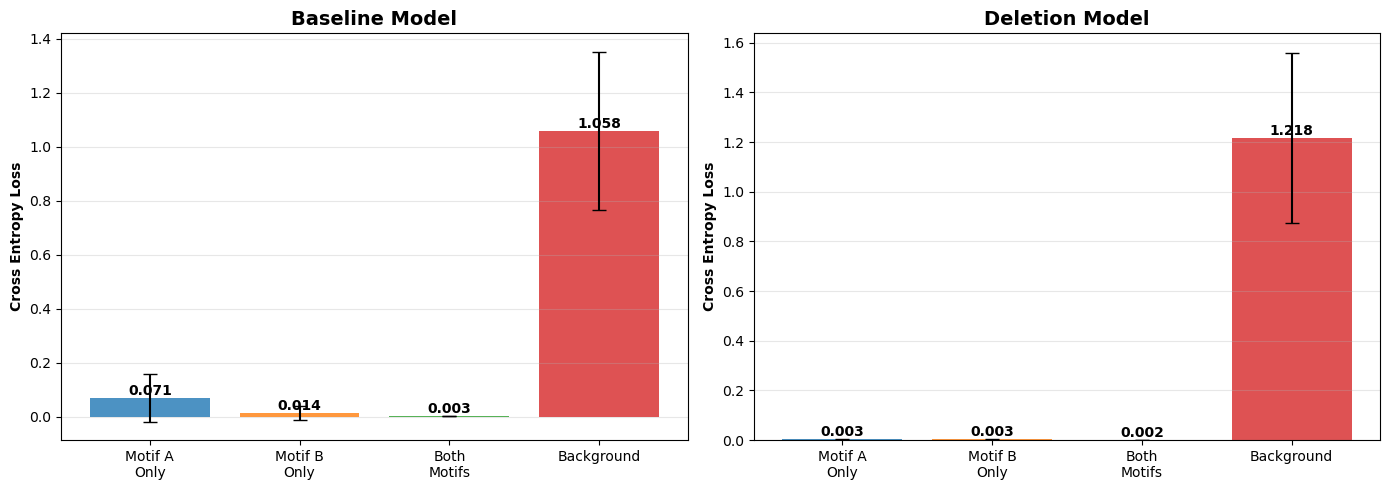


Baseline:
  Motif A only:  0.071 (n=38)
  Motif B only:  0.014 (n=45)
  Both motifs:   0.003 (n=18)
  Background:    1.058 (n=101)

Deletion:
  Motif A only:  0.003 (n=38)
  Motif B only:  0.003 (n=45)
  Both motifs:   0.002 (n=18)
  Background:    1.218 (n=101)


In [11]:
# Minimal cross-entropy analysis for all test data
import matplotlib.pyplot as plt
import numpy as np

def test_motifs_combined(seq, model, tokenizer, motif_list, device):
    """Test multiple motifs by masking ONE token at a time and averaging"""
    tokens = [tokenizer._convert_token_to_id(c) for c in seq if tokenizer._convert_token_to_id(c) is not None]
    cls_id = tokenizer._convert_token_to_id('[CLS]')
    sep_id = tokenizer._convert_token_to_id('[SEP]')
    mask_id = tokenizer._convert_token_to_id('[MASK]')
    input_ids = [cls_id] + tokens + [sep_id]
    
    # Find all motif positions
    motif_positions = []  # List of (start, end, motif_tokens)
    for motif in motif_list:
        for m in re.finditer(motif, seq):
            start, end = m.span()
            motif_tokens = [tokenizer._convert_token_to_id(c) for c in motif]
            motif_positions.append((start, end, motif_tokens))
    
    if not motif_positions:
        return None
    
    # Collect losses for each individual masked position
    all_losses = []
    
    for start, end, motif_tokens in motif_positions:
        for i, token in enumerate(motif_tokens):
            pos = start + 1 + i  # +1 for [CLS] token
            if pos >= len(input_ids) - 1:  # Skip if position is invalid
                continue
            
            # Create masked input with ONLY this position masked
            masked = input_ids.copy()
            masked[pos] = mask_id
            
            # Get predictions
            with torch.no_grad():
                output = model(torch.tensor([masked], device=device), return_dict=True)
                logits = output.logits[0]
            
            # Calculate loss for this single position
            pred_logit = logits[pos].unsqueeze(0)  # Shape: (1, vocab_size)
            truth_token = torch.tensor([token], device=device)  # Shape: (1,)
            
            loss = F.cross_entropy(pred_logit, truth_token)
            all_losses.append(loss.item())
    
    # Return average loss across all individual masked positions
    return sum(all_losses) / len(all_losses) if all_losses else None

def analyze_dataset(data, model, tokenizer, device):
    """Analyze all sequences - categorize by motif presence"""
    results = {'motif_a': [], 'motif_b': [], 'both': [], 'background': []}
    avg_motif_len = int((len(motifs[0]) + len(motifs[1])) / 2)
    
    for count, (idx, row) in enumerate(data.iterrows()):
        if count % 10 == 0:
            print(f"Processing {count}...")
        
        if count > 100:
            break
        seq = row['sequences']
        
        # Check which motifs are present
        has_a = motifs[0] in seq
        has_b = motifs[1] in seq
        
        if has_a and has_b:
            # Sequence has BOTH motifs - mask ALL occurrences of BOTH at once
            loss = test_motifs_combined(seq, model, tokenizer, motifs, device)
            if loss is not None:
                results['both'].append(loss)
        elif has_a:
            # Only motif A - mask all occurrences of A
            loss = test_motifs_combined(seq, model, tokenizer, [motifs[0]], device)
            if loss is not None:
                results['motif_a'].append(loss)
        elif has_b:
            # Only motif B - mask all occurrences of B
            loss = test_motifs_combined(seq, model, tokenizer, [motifs[1]], device)
            if loss is not None:
                results['motif_b'].append(loss)
        
        # Test background (1 random chunk per sequence, avg motif length)
        motif_regions = set()
        for motif in motifs:
            for m in re.finditer(motif, seq):
                motif_regions.update(range(m.start(), m.end()))
        
        available = [pos for pos in range(len(seq)-avg_motif_len) if not any(p in motif_regions for p in range(pos, pos+avg_motif_len))]
        if available:
            start = np.random.choice(available)
            bg_chunk = seq[start:start+avg_motif_len*2]
            bg_loss = test_motifs_combined(seq, model, tokenizer, [bg_chunk], device)
            if bg_loss is not None:
                results['background'].append(bg_loss)
    
    return results

# Run analysis
print("Analyzing baseline model...")
baseline = analyze_dataset(test_data, model, tokenizer, device)
print("Analyzing deletion model...")
deletion = analyze_dataset(del_test_data, del_model, del_tokenizer, device)

# Print counts
print(f"\nBaseline - Motif A only: {len(baseline['motif_a'])}, Motif B only: {len(baseline['motif_b'])}, Both: {len(baseline['both'])}, Background: {len(baseline['background'])}")
print(f"Deletion - Motif A only: {len(deletion['motif_a'])}, Motif B only: {len(deletion['motif_b'])}, Both: {len(deletion['both'])}, Background: {len(deletion['background'])}")

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
categories = ['Motif A\nOnly', 'Motif B\nOnly', 'Both\nMotifs', 'Background']

for ax, (name, res) in zip(axes, [('Baseline', baseline), ('Deletion', deletion)]):
    means = [np.mean(res[k]) if res[k] else 0 for k in ['motif_a', 'motif_b', 'both', 'background']]
    stds = [np.std(res[k]) if res[k] else 0 for k in ['motif_a', 'motif_b', 'both', 'background']]
    
    bars = ax.bar(categories, means, yerr=stds, capsize=5, alpha=0.8, 
                   color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
    ax.set_title(f'{name} Model', fontweight='bold', fontsize=14)
    ax.set_ylabel('Cross Entropy Loss', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    for bar, m in zip(bars, means):
        if m > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                    f'{m:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('motif_cross_entropy.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary
for name, res in [('Baseline', baseline), ('Deletion', deletion)]:
    print(f"\n{name}:")
    print(f"  Motif A only:  {np.mean(res['motif_a']):.3f} (n={len(res['motif_a'])})")
    print(f"  Motif B only:  {np.mean(res['motif_b']):.3f} (n={len(res['motif_b'])})")
    print(f"  Both motifs:   {np.mean(res['both']):.3f} (n={len(res['both'])})")
    print(f"  Background:    {np.mean(res['background']):.3f} (n={len(res['background'])})")


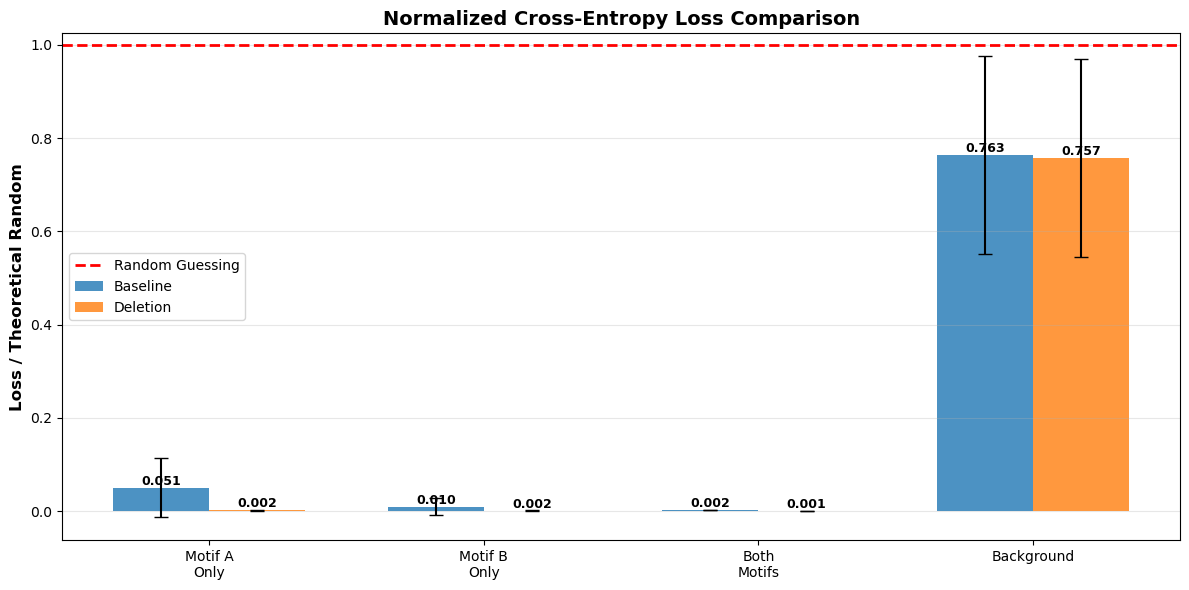

Theoretical: ln(4)=1.3863, ln(5)=1.6094
Baseline: A=0.051, B=0.010, Both=0.002, Bg=0.763
Deletion: A=0.002, B=0.002, Both=0.001, Bg=0.757


In [12]:
# Single normalized comparison plot
baseline_norm = {k: [l/np.log(4) for l in v] for k, v in baseline.items()}
deletion_norm = {k: [l/np.log(5) for l in v] for k, v in deletion.items()}

fig, ax = plt.subplots(figsize=(12, 6))
categories = ['Motif A\nOnly', 'Motif B\nOnly', 'Both\nMotifs', 'Background']
x = np.arange(len(categories))
width = 0.35

base_means = [np.mean(baseline_norm[k]) if baseline_norm[k] else 0 for k in ['motif_a', 'motif_b', 'both', 'background']]
del_means = [np.mean(deletion_norm[k]) if deletion_norm[k] else 0 for k in ['motif_a', 'motif_b', 'both', 'background']]
base_stds = [np.std(baseline_norm[k]) if baseline_norm[k] else 0 for k in ['motif_a', 'motif_b', 'both', 'background']]
del_stds = [np.std(deletion_norm[k]) if deletion_norm[k] else 0 for k in ['motif_a', 'motif_b', 'both', 'background']]

bars1 = ax.bar(x - width/2, base_means, width, yerr=base_stds, capsize=5, label='Baseline', alpha=0.8)
bars2 = ax.bar(x + width/2, del_means, width, yerr=del_stds, capsize=5, label='Deletion', alpha=0.8)

ax.set_ylabel('Loss / Theoretical Random', fontweight='bold', fontsize=12)
ax.set_title('Normalized Cross-Entropy Loss Comparison', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Random Guessing')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}',
                   ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('motif_cross_entropy_normalized.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Theoretical: ln(4)={np.log(4):.4f}, ln(5)={np.log(5):.4f}")
for name, res in [('Baseline', baseline_norm), ('Deletion', deletion_norm)]:
    print(f"{name}: A={np.mean(res['motif_a']):.3f}, B={np.mean(res['motif_b']):.3f}, "
          f"Both={np.mean(res['both']):.3f}, Bg={np.mean(res['background']):.3f}")


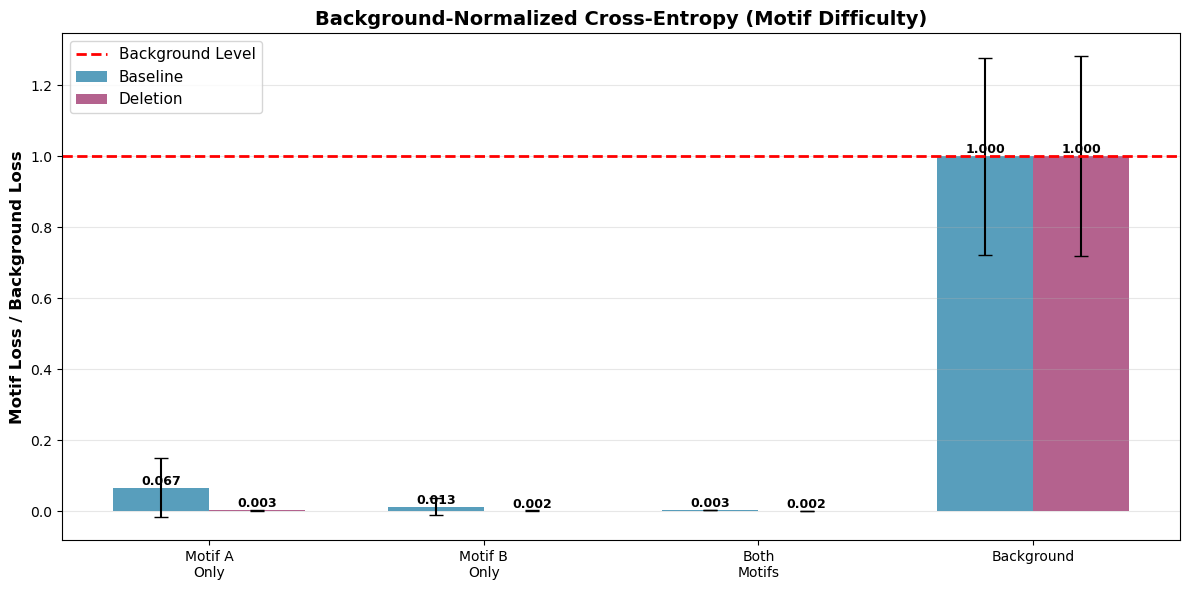


BACKGROUND-NORMALIZED CROSS-ENTROPY
Baseline background: 1.0583
Deletion background: 1.2177
------------------------------------------------------------

Baseline (relative to its background):
  Motif A   : 0.067x background (EASIER to predict)
  Motif B   : 0.013x background (EASIER to predict)
  Both      : 0.003x background (EASIER to predict)

Deletion (relative to its background):
  Motif A   : 0.003x background (EASIER to predict)
  Motif B   : 0.002x background (EASIER to predict)
  Both      : 0.002x background (EASIER to predict)

INTERPRETATION:
  < 1.0 = Motif is EASIER to predict than random background
  > 1.0 = Motif is HARDER to predict than random background
  = 1.0 = Motif has same difficulty as background


In [14]:
# Background-normalized comparison (better than theoretical random)
fig, ax = plt.subplots(figsize=(12, 6))
categories = ['Motif A\nOnly', 'Motif B\nOnly', 'Both\nMotifs', 'Background']
x = np.arange(len(categories))
width = 0.35

# Normalize by background loss (empirical baseline)
base_bg_mean = np.mean(baseline['background'])
del_bg_mean = np.mean(deletion['background'])

base_norm = {k: [l/base_bg_mean for l in v] for k, v in baseline.items()}
del_norm = {k: [l/del_bg_mean for l in v] for k, v in deletion.items()}

base_means = [np.mean(base_norm[k]) if base_norm[k] else 0 for k in ['motif_a', 'motif_b', 'both', 'background']]
del_means = [np.mean(del_norm[k]) if del_norm[k] else 0 for k in ['motif_a', 'motif_b', 'both', 'background']]
base_stds = [np.std(base_norm[k]) if base_norm[k] else 0 for k in ['motif_a', 'motif_b', 'both', 'background']]
del_stds = [np.std(del_norm[k]) if del_norm[k] else 0 for k in ['motif_a', 'motif_b', 'both', 'background']]

bars1 = ax.bar(x - width/2, base_means, width, yerr=base_stds, capsize=5, label='Baseline', alpha=0.8, color='#2E86AB')
bars2 = ax.bar(x + width/2, del_means, width, yerr=del_stds, capsize=5, label='Deletion', alpha=0.8, color='#A23B72')

ax.set_ylabel('Motif Loss / Background Loss', fontweight='bold', fontsize=12)
ax.set_title('Background-Normalized Cross-Entropy (Motif Difficulty)', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Background Level')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}',
                   ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('motif_cross_entropy_background_norm.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistical comparison
print(f"\n{'='*60}")
print("BACKGROUND-NORMALIZED CROSS-ENTROPY")
print(f"{'='*60}")
print(f"Baseline background: {base_bg_mean:.4f}")
print(f"Deletion background: {del_bg_mean:.4f}")
print(f"{'-'*60}")

for name, norm_res in [('Baseline', base_norm), ('Deletion', del_norm)]:
    print(f"\n{name} (relative to its background):")
    for cat, label in [('motif_a', 'Motif A'), ('motif_b', 'Motif B'), ('both', 'Both')]:
        mean_val = np.mean(norm_res[cat]) if norm_res[cat] else 0
        interpretation = "EASIER" if mean_val < 1.0 else "HARDER"
        print(f"  {label:10s}: {mean_val:.3f}x background ({interpretation} to predict)")

print(f"\n{'='*60}")
print("INTERPRETATION:")
print("  < 1.0 = Motif is EASIER to predict than random background")
print("  > 1.0 = Motif is HARDER to predict than random background")
print("  = 1.0 = Motif has same difficulty as background")
print(f"{'='*60}")

Testing 100 baseline sequences, 100 deletion sequences
Processing k=1...
Processing k=2...
Processing k=2...
Processing k=3...
Processing k=3...
Processing k=4...
Processing k=4...
Processing k=5...
Processing k=5...
Processing k=6...
Processing k=6...
Processing k=7...
Processing k=7...
Processing k=8...
Processing k=8...

k    Baseline Δ      Deletion Δ      n_base   n_del   
------------------------------------------------------------
1    +0.0302 (±0.0299)  +0.0000 (±0.0000)  100      100     
2    +0.0983 (±0.0620)  +0.0000 (±0.0000)  100      100     
3    +0.2191 (±0.0797)  +0.0000 (±0.0000)  100      100     
4    +0.3595 (±0.1277)  +0.0000 (±0.0000)  100      100     
5    +0.5058 (±0.1306)  +0.0001 (±0.0000)  100      100     
6    +0.1931 (±0.2361)  +0.0001 (±0.0000)  100      100     
7    +0.0699 (±0.1939)  +0.0000 (±0.0000)  100      100     
8    +0.0339 (±0.1408)  +0.0000 (±0.0000)  100      100     

k    Baseline Δ      Deletion Δ      n_base   n_del   
--------------

Testing 100 baseline sequences, 100 deletion sequences
Processing k=1...
Processing k=2...
Processing k=2...
Processing k=3...
Processing k=3...
Processing k=4...
Processing k=4...
Processing k=5...
Processing k=5...
Processing k=6...
Processing k=6...
Processing k=7...
Processing k=7...
Processing k=8...
Processing k=8...

k    Baseline Δ      Deletion Δ      n_base   n_del   
------------------------------------------------------------
1    +0.0302 (±0.0299)  +0.0000 (±0.0000)  100      100     
2    +0.0983 (±0.0620)  +0.0000 (±0.0000)  100      100     
3    +0.2191 (±0.0797)  +0.0000 (±0.0000)  100      100     
4    +0.3595 (±0.1277)  +0.0000 (±0.0000)  100      100     
5    +0.5058 (±0.1306)  +0.0001 (±0.0000)  100      100     
6    +0.1931 (±0.2361)  +0.0001 (±0.0000)  100      100     
7    +0.0699 (±0.1939)  +0.0000 (±0.0000)  100      100     
8    +0.0339 (±0.1408)  +0.0000 (±0.0000)  100      100     

k    Baseline Δ      Deletion Δ      n_base   n_del   
--------------

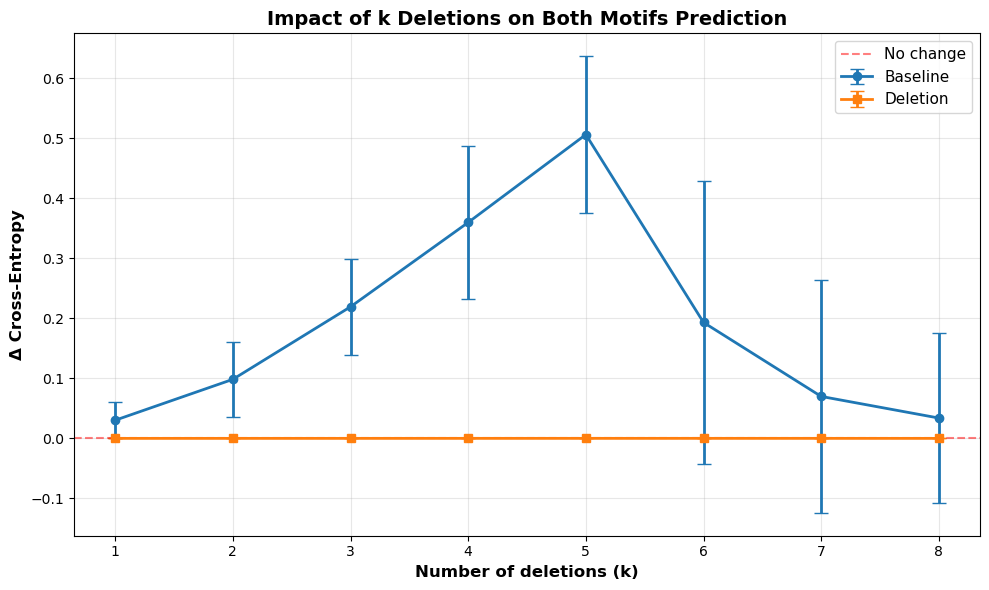

In [20]:
# Test biological distance shift with k deletions across all sequences
def calc_ce_both_motifs(seq, model, tokenizer, motif_a, motif_b, device):
    """Calculate CE for both motifs and average"""
    losses = []
    
    # Process Motif A
    match_a = re.search(motif_a, seq)
    if match_a:
        start = match_a.start()
        tokens = [tokenizer._convert_token_to_id(c) for c in seq if tokenizer._convert_token_to_id(c) is not None]
        input_ids = [tokenizer._convert_token_to_id('[CLS]')] + tokens + [tokenizer._convert_token_to_id('[SEP]')]
        mask_id = tokenizer._convert_token_to_id('[MASK]')
        
        for i, c in enumerate(motif_a):
            pos = start + 1 + i
            masked = input_ids.copy()
            masked[pos] = mask_id
            with torch.no_grad():
                logits = model(torch.tensor([masked], device=device), return_dict=True).logits[0]
            loss = F.cross_entropy(logits[pos].unsqueeze(0), torch.tensor([tokenizer._convert_token_to_id(c)], device=device))
            losses.append(loss.item())
    
    # Process Motif B
    match_b = re.search(motif_b, seq)
    if match_b:
        start = match_b.start()
        tokens = [tokenizer._convert_token_to_id(c) for c in seq if tokenizer._convert_token_to_id(c) is not None]
        input_ids = [tokenizer._convert_token_to_id('[CLS]')] + tokens + [tokenizer._convert_token_to_id('[SEP]')]
        mask_id = tokenizer._convert_token_to_id('[MASK]')
        
        for i, c in enumerate(motif_b):
            pos = start + 1 + i
            masked = input_ids.copy()
            masked[pos] = mask_id
            with torch.no_grad():
                logits = model(torch.tensor([masked], device=device), return_dict=True).logits[0]
            loss = F.cross_entropy(logits[pos].unsqueeze(0), torch.tensor([tokenizer._convert_token_to_id(c)], device=device))
            losses.append(loss.item())
    
    return np.mean(losses) if losses else None

# Collect all sequences with both motifs
base_seqs = [(row['sequences'], re.search(motifs[0], row['sequences']).span(), re.search(motifs[1], row['sequences']).span()) 
             for _, row in test_data.iterrows() if motifs[0] in row['sequences'] and motifs[1] in row['sequences']][:100]
del_seqs = [(row['sequences'], re.search(motifs[0], row['sequences']).span(), re.search(motifs[1], row['sequences']).span()) 
            for _, row in del_test_data.iterrows() if motifs[0] in row['sequences'] and motifs[1] in row['sequences']][:100]

print(f"Testing {len(base_seqs)} baseline sequences, {len(del_seqs)} deletion sequences")

# Store results for each k
k_values = [1, 2, 3, 4, 5, 6, 7, 8]
results = {k: {'base_deltas': [], 'del_deltas': []} for k in k_values}

for k in k_values:
    print(f"Processing k={k}...")
    
    # Baseline sequences
    for seq, pos_a, pos_b in base_seqs:
        gap_start, gap_end = pos_a[1], pos_b[0]
        if k > (gap_end - gap_start): continue
        
        orig = calc_ce_both_motifs(seq, model, tokenizer, motifs[0], motifs[1], device)
        if orig is None: continue
        
        gap_mid = (gap_start + gap_end) // 2
        mod_seq = seq[:gap_mid] + seq[gap_mid+k:] + ''.join(np.random.choice(['A','C','G','T'], k))
        mod = calc_ce_both_motifs(mod_seq, model, tokenizer, motifs[0], motifs[1], device)
        if mod is not None:
            results[k]['base_deltas'].append(mod - orig)
    
    # Deletion sequences
    for seq, pos_a, pos_b in del_seqs:
        gap_start, gap_end = pos_a[1], pos_b[0]
        if k > (gap_end - gap_start): continue
        
        orig = calc_ce_both_motifs(seq, del_model, del_tokenizer, motifs[0], motifs[1], device)
        if orig is None: continue
        
        gap_mid = (gap_start + gap_end) // 2
        mod_seq = seq[:gap_mid] + '-'*k + seq[gap_mid+k:]
        mod = calc_ce_both_motifs(mod_seq, del_model, del_tokenizer, motifs[0], motifs[1], device)
        if mod is not None:
            results[k]['del_deltas'].append(mod - orig)

# Print results
print(f"\n{'k':<4} {'Baseline Δ':<15} {'Deletion Δ':<15} {'n_base':<8} {'n_del':<8}")
print("-" * 60)
for k in k_values:
    base_mean = np.mean(results[k]['base_deltas']) if results[k]['base_deltas'] else 0
    del_mean = np.mean(results[k]['del_deltas']) if results[k]['del_deltas'] else 0
    n_base = len(results[k]['base_deltas'])
    n_del = len(results[k]['del_deltas'])
    print(f"{k:<4} {base_mean:+.4f} (±{np.std(results[k]['base_deltas']):.4f})  {del_mean:+.4f} (±{np.std(results[k]['del_deltas']):.4f})  {n_base:<8} {n_del:<8}")

# Plot results
fig, ax = plt.subplots(figsize=(10, 6))
base_means = [np.mean(results[k]['base_deltas']) if results[k]['base_deltas'] else 0 for k in k_values]
del_means = [np.mean(results[k]['del_deltas']) if results[k]['del_deltas'] else 0 for k in k_values]
base_stds = [np.std(results[k]['base_deltas']) if results[k]['base_deltas'] else 0 for k in k_values]
del_stds = [np.std(results[k]['del_deltas']) if results[k]['del_deltas'] else 0 for k in k_values]

ax.errorbar(k_values, base_means, yerr=base_stds, marker='o', capsize=5, label='Baseline', linewidth=2)
ax.errorbar(k_values, del_means, yerr=del_stds, marker='s', capsize=5, label='Deletion', linewidth=2)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='No change')
ax.set_xlabel('Number of deletions (k)', fontweight='bold', fontsize=12)
ax.set_ylabel('Δ Cross-Entropy', fontweight='bold', fontsize=12)
ax.set_title('Impact of k Deletions on Both Motifs Prediction', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('biological_distance_shift.png', dpi=300, bbox_inches='tight')
plt.show()

Testing 100 baseline sequences, 100 deletion sequences
Processing k=1...
Processing k=2...
Processing k=2...
Processing k=3...
Processing k=3...
Processing k=4...
Processing k=4...
Processing k=5...
Processing k=5...

k    Baseline Δ      Deletion Δ      n_base   n_del   
------------------------------------------------------------
1    +0.0306 (±0.0301)  +0.0000 (±0.0000)  100      100     
2    +0.0986 (±0.0619)  +0.0000 (±0.0000)  100      100     
3    +0.2244 (±0.0807)  +0.0000 (±0.0000)  100      100     
4    +0.3522 (±0.1342)  +0.0000 (±0.0000)  100      100     
5    +0.5077 (±0.1252)  +0.0001 (±0.0000)  100      100     

k    Baseline Δ      Deletion Δ      n_base   n_del   
------------------------------------------------------------
1    +0.0306 (±0.0301)  +0.0000 (±0.0000)  100      100     
2    +0.0986 (±0.0619)  +0.0000 (±0.0000)  100      100     
3    +0.2244 (±0.0807)  +0.0000 (±0.0000)  100      100     
4    +0.3522 (±0.1342)  +0.0000 (±0.0000)  100      100     


Testing 100 baseline sequences, 100 deletion sequences
Processing k=1...
Processing k=2...
Processing k=2...
Processing k=3...
Processing k=3...
Processing k=4...
Processing k=4...
Processing k=5...
Processing k=5...

k    Baseline Δ      Deletion Δ      n_base   n_del   
------------------------------------------------------------
1    +0.0306 (±0.0301)  +0.0000 (±0.0000)  100      100     
2    +0.0986 (±0.0619)  +0.0000 (±0.0000)  100      100     
3    +0.2244 (±0.0807)  +0.0000 (±0.0000)  100      100     
4    +0.3522 (±0.1342)  +0.0000 (±0.0000)  100      100     
5    +0.5077 (±0.1252)  +0.0001 (±0.0000)  100      100     

k    Baseline Δ      Deletion Δ      n_base   n_del   
------------------------------------------------------------
1    +0.0306 (±0.0301)  +0.0000 (±0.0000)  100      100     
2    +0.0986 (±0.0619)  +0.0000 (±0.0000)  100      100     
3    +0.2244 (±0.0807)  +0.0000 (±0.0000)  100      100     
4    +0.3522 (±0.1342)  +0.0000 (±0.0000)  100      100     


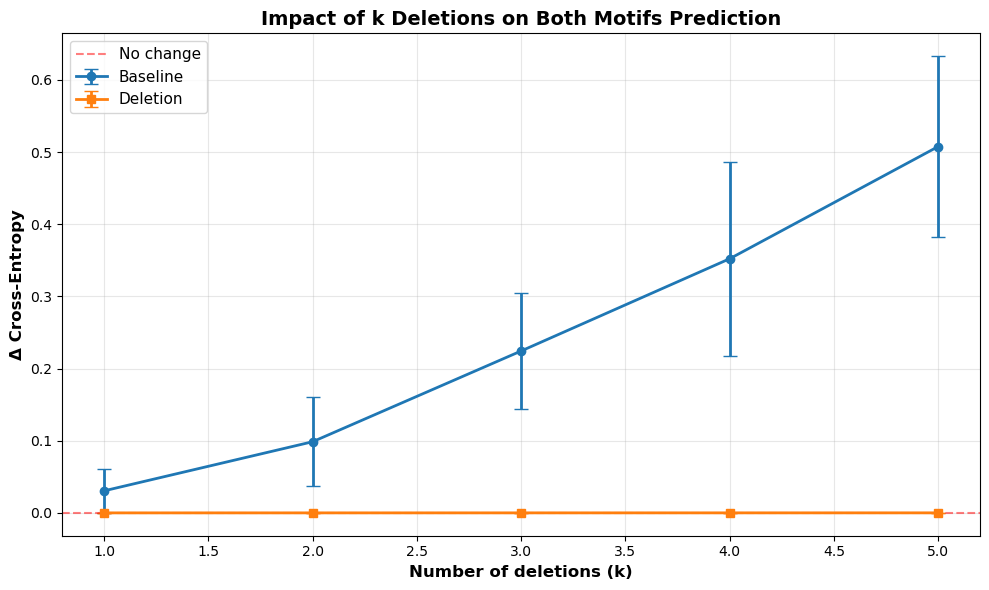

In [23]:
# Test biological distance shift with k deletions across all sequences
def calc_ce_both_motifs(seq, model, tokenizer, motif_a, motif_b, device):
    """Calculate CE for both motifs and average"""
    losses = []
    
    # Process Motif A
    match_a = re.search(motif_a, seq)
    if match_a:
        start = match_a.start()
        tokens = [tokenizer._convert_token_to_id(c) for c in seq if tokenizer._convert_token_to_id(c) is not None]
        input_ids = [tokenizer._convert_token_to_id('[CLS]')] + tokens + [tokenizer._convert_token_to_id('[SEP]')]
        mask_id = tokenizer._convert_token_to_id('[MASK]')
        
        for i, c in enumerate(motif_a):
            pos = start + 1 + i
            masked = input_ids.copy()
            masked[pos] = mask_id
            with torch.no_grad():
                logits = model(torch.tensor([masked], device=device), return_dict=True).logits[0]
            loss = F.cross_entropy(logits[pos].unsqueeze(0), torch.tensor([tokenizer._convert_token_to_id(c)], device=device))
            losses.append(loss.item())
    
    # Process Motif B
    match_b = re.search(motif_b, seq)
    if match_b:
        start = match_b.start()
        tokens = [tokenizer._convert_token_to_id(c) for c in seq if tokenizer._convert_token_to_id(c) is not None]
        input_ids = [tokenizer._convert_token_to_id('[CLS]')] + tokens + [tokenizer._convert_token_to_id('[SEP]')]
        mask_id = tokenizer._convert_token_to_id('[MASK]')
        
        for i, c in enumerate(motif_b):
            pos = start + 1 + i
            masked = input_ids.copy()
            masked[pos] = mask_id
            with torch.no_grad():
                logits = model(torch.tensor([masked], device=device), return_dict=True).logits[0]
            loss = F.cross_entropy(logits[pos].unsqueeze(0), torch.tensor([tokenizer._convert_token_to_id(c)], device=device))
            losses.append(loss.item())
    
    return np.mean(losses) if losses else None

# Collect all sequences with both motifs
base_seqs = [(row['sequences'], re.search(motifs[0], row['sequences']).span(), re.search(motifs[1], row['sequences']).span()) 
             for _, row in test_data.iterrows() if motifs[0] in row['sequences'] and motifs[1] in row['sequences']][:100]
del_seqs = [(row['sequences'], re.search(motifs[0], row['sequences']).span(), re.search(motifs[1], row['sequences']).span()) 
            for _, row in del_test_data.iterrows() if motifs[0] in row['sequences'] and motifs[1] in row['sequences']][:100]

print(f"Testing {len(base_seqs)} baseline sequences, {len(del_seqs)} deletion sequences")

# Store results for each k
k_values = [1, 2, 3, 4, 5]
results = {k: {'base_deltas': [], 'del_deltas': []} for k in k_values}

for k in k_values:
    print(f"Processing k={k}...")
    
    # Baseline sequences
    for seq, pos_a, pos_b in base_seqs:
        gap_start, gap_end = pos_a[1], pos_b[0]
        if k > (gap_end - gap_start): continue
        
        orig = calc_ce_both_motifs(seq, model, tokenizer, motifs[0], motifs[1], device)
        if orig is None: continue
        
        gap_mid = (gap_start + gap_end) // 2
        mod_seq = seq[:gap_mid] + seq[gap_mid+k:] + ''.join(np.random.choice(['A','C','G','T'], k))
        mod = calc_ce_both_motifs(mod_seq, model, tokenizer, motifs[0], motifs[1], device)
        if mod is not None:
            results[k]['base_deltas'].append(mod - orig)
    
    # Deletion sequences
    for seq, pos_a, pos_b in del_seqs:
        gap_start, gap_end = pos_a[1], pos_b[0]
        if k > (gap_end - gap_start): continue
        
        orig = calc_ce_both_motifs(seq, del_model, del_tokenizer, motifs[0], motifs[1], device)
        if orig is None: continue
        
        gap_mid = (gap_start + gap_end) // 2
        mod_seq = seq[:gap_mid] + '-'*k + seq[gap_mid+k:]
        mod = calc_ce_both_motifs(mod_seq, del_model, del_tokenizer, motifs[0], motifs[1], device)
        if mod is not None:
            results[k]['del_deltas'].append(mod - orig)

# Print results
print(f"\n{'k':<4} {'Baseline Δ':<15} {'Deletion Δ':<15} {'n_base':<8} {'n_del':<8}")
print("-" * 60)
for k in k_values:
    base_mean = np.mean(results[k]['base_deltas']) if results[k]['base_deltas'] else 0
    del_mean = np.mean(results[k]['del_deltas']) if results[k]['del_deltas'] else 0
    n_base = len(results[k]['base_deltas'])
    n_del = len(results[k]['del_deltas'])
    print(f"{k:<4} {base_mean:+.4f} (±{np.std(results[k]['base_deltas']):.4f})  {del_mean:+.4f} (±{np.std(results[k]['del_deltas']):.4f})  {n_base:<8} {n_del:<8}")

# Plot results
fig, ax = plt.subplots(figsize=(10, 6))
base_means = [np.mean(results[k]['base_deltas']) if results[k]['base_deltas'] else 0 for k in k_values]
del_means = [np.mean(results[k]['del_deltas']) if results[k]['del_deltas'] else 0 for k in k_values]
base_stds = [np.std(results[k]['base_deltas']) if results[k]['base_deltas'] else 0 for k in k_values]
del_stds = [np.std(results[k]['del_deltas']) if results[k]['del_deltas'] else 0 for k in k_values]

ax.errorbar(k_values, base_means, yerr=base_stds, marker='o', capsize=5, label='Baseline', linewidth=2)
ax.errorbar(k_values, del_means, yerr=del_stds, marker='s', capsize=5, label='Deletion', linewidth=2)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='No change')
ax.set_xlabel('Number of deletions (k)', fontweight='bold', fontsize=12)
ax.set_ylabel('Δ Cross-Entropy', fontweight='bold', fontsize=12)
ax.set_title('Impact of k Deletions on Both Motifs Prediction', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('biological_distance_shift.png', dpi=300, bbox_inches='tight')
plt.show()

In [45]:
print(base_seqs[49][0])

CGTAGGTCTCGGTCTGACGTAACGCTCCAA


In [46]:
print(del_seqs[49][0])  

CGTAGGTCTCGGT-TGACGGTAACGCTCC-


In [ ]:
calc_ce_both_motifs("[MASK]GTAGGTCGAGGTAAATTGTAACGCTCCGG", model, tokenizer, motifs[0], motifs[1], device)

In [48]:
motifs[0]

'CGTAGGTC'

In [62]:
# Minimal demo: Cross-entropy with 1 deletion
# Edit the sequences below to experiment!

# BASELINE sequence (no gaps)
base_seq = "CGTAGGTCTCGGTCTGACGTAACGCTCCAA"

# DELETION sequence (with gaps)
del_seq = "CGTAGGTCTCGGT-TGACGGTAACGCTCC-"

k = 3  # Number of deletions to add

# ANSI color codes
BLUE = '\033[94m'    # Motif A
GREEN = '\033[92m'   # Motif B
RED = '\033[91m'     # Deleted region
YELLOW = '\033[93m'  # Added region
RESET = '\033[0m'

def colorize_seq(seq, pos_a, pos_b, delete_start=None, delete_end=None, add_start=None, add_end=None):
    """Add color to sequence highlighting motifs and modifications"""
    result = ""
    for i, char in enumerate(seq):
        if delete_start and delete_start <= i < delete_end:
            result += f"{RED}{char}{RESET}"
        elif add_start and add_start <= i < add_end:
            result += f"{YELLOW}{char}{RESET}"
        elif pos_a[0] <= i < pos_a[1]:
            result += f"{BLUE}{char}{RESET}"
        elif pos_b[0] <= i < pos_b[1]:
            result += f"{GREEN}{char}{RESET}"
        else:
            result += char
    return result

print("="*60)
print("BASELINE MODEL")
print("="*60)

# Find motif positions in baseline sequence
pos_a = re.search(motifs[0], base_seq).span()
pos_b = re.search(motifs[1], base_seq).span()
gap_start, gap_end = pos_a[1], pos_b[0]

# Original baseline CE
orig_base = calc_ce_both_motifs(base_seq, model, tokenizer, motifs[0], motifs[1], device)
gap_mid = (gap_start + gap_end) // 2
print(f"Original: {colorize_seq(base_seq, pos_a, pos_b)}")
print(f"          {BLUE}Motif A{RESET} | {GREEN}Motif B{RESET}")
print(f"CE: {orig_base:.4f}\n")

# Delete k random tokens between motifs, add k random at end
random_bases = ''.join(np.random.choice(['A','C','G','T'], k))
mod_base_seq = base_seq[:gap_mid] + base_seq[gap_mid+k:] + random_bases
# Find new motif positions after modification
pos_a_mod = re.search(motifs[0], mod_base_seq).span()
pos_b_mod = (pos_b[0] - k, pos_b[1] - k)  # Shifted by k
add_start = len(mod_base_seq) - k

print(f"Modified: {colorize_seq(base_seq, pos_a, pos_b, gap_mid, gap_mid+k)}")
print(f"          {RED}← deleted {k} bases here{RESET}")
print(f"Modified: {colorize_seq(mod_base_seq, pos_a_mod, pos_b_mod, add_start=add_start, add_end=len(mod_base_seq))}")
print(f"          {YELLOW}← added {k} random bases at end{RESET}")
mod_base = calc_ce_both_motifs(mod_base_seq, model, tokenizer, motifs[0], motifs[1], device)
print(f"CE: {mod_base:.4f}")
print(f"Δ CE: {mod_base - orig_base:+.4f}\n")

print("="*60)
print("DELETION MODEL")
print("="*60)

# Find motif positions in deletion sequence
pos_a_del = re.search(motifs[0], del_seq).span()
pos_b_del = re.search(motifs[1], del_seq).span()
gap_start_del, gap_end_del = pos_a_del[1], pos_b_del[0]

# Original deletion CE
orig_del = calc_ce_both_motifs(del_seq, del_model, del_tokenizer, motifs[0], motifs[1], device)
gap_mid_del = (gap_start_del + gap_end_del) // 2
print(f"Original: {colorize_seq(del_seq, pos_a_del, pos_b_del)}")
print(f"          {BLUE}Motif A{RESET} | {GREEN}Motif B{RESET}")
print(f"CE: {orig_del:.4f}\n")

# Replace k random tokens between motifs with '-'
mod_del_seq = del_seq[:gap_mid_del] + '-'*k + del_seq[gap_mid_del+k:]
# Find new motif positions (shouldn't change)
pos_a_del_mod = re.search(motifs[0], mod_del_seq).span()
pos_b_del_mod = re.search(motifs[1], mod_del_seq).span()

print(f"Modified: {colorize_seq(del_seq, pos_a_del, pos_b_del, gap_mid_del, gap_mid_del+k)}")
print(f"          {RED}← replaced {k} bases with gaps{RESET}")
print(f"Modified: {colorize_seq(mod_del_seq, pos_a_del_mod, pos_b_del_mod, delete_start=gap_mid_del, delete_end=gap_mid_del+k)}")
mod_del = calc_ce_both_motifs(mod_del_seq, del_model, del_tokenizer, motifs[0], motifs[1], device)
print(f"CE: {mod_del:.4f}")
print(f"Δ CE: {mod_del - orig_del:+.4f}")


BASELINE MODEL
Original: CGTAGGTCTCGGTCTGACGTAACGCTCCAA
          Motif A | Motif B
CE: 0.0030

Modified: CGTAGGTCTCGGTCTGACGTAACGCTCCAA
          ← deleted 3 bases here
Modified: CGTAGGTCTCGGTACGTAACGCTCCAACGA
          ← added 3 random bases at end
CE: 0.2523
Δ CE: +0.2494

DELETION MODEL
Original: CGTAGGTCTCGGT-TGACGGTAACGCTCC-
          Motif A | Motif B
CE: 0.0020

Modified: CGTAGGTCTCGGT-TGACGGTAACGCTCC-
          ← replaced 3 bases with gaps
Modified: CGTAGGTCTCGGT---ACGGTAACGCTCC-
CE: 0.0020
Δ CE: +0.0000
CE: 0.0020
Δ CE: +0.0000
